# **Diagnosing unbounded problems**

***diagnose_unbounded.ipynb***

In this example, we demonstrate how to use primal rays to programmatically identify and diagnose variables contributing to unboundedness in LP problems. For diagnosing infeasible problems using IIS (Irreducible Infeasible Sets) for several problem types, see [diagnose_infeasible.ipynb](diagnose_infeasible.ipynb).

&copy; Copyright 2025-2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/python-notebooks#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q xpress matplotlib scipy

## How to diagnose an unbounded LP problem

A problem is said to be *unbounded* if the objective function may be improved indefinitely without violating the constraints and bounds. This can happen if a problem is being solved with the wrong optimization sense, e.g., a maximization problem is being minimized. However, when a problem is unbounded and the problem is being solved with the correct optimization sense then this indicates a problem in the formulation of the model or the data. Typically, the problem is caused by missing constraints or having wrong signs on the coefficients.

When the solver identifies a problem as unbounded, it may report a specific row that causes the unboundedness during presolve (e.g., "<tt>The problem is unbounded due to row _R35494"</tt>). However, to programmatically retrieve this information and present it in a human-readable format for troubleshooting, we need to use **primal rays**.

A primal ray (also called an unbounded direction) is a *vector that indicates a direction in which the objective can improve indefinitely without violating any constraints*. Geometrically, if $(x_1, x_2, \ldots, x_n)$ is any feasible point and $(r_1, r_2, \ldots, r_n)$ is the primal ray, then the point $(x_1 + \alpha \cdot r_1, x_2 + \alpha \cdot r_2, \ldots, x_n + \alpha \cdot r_n)$ remains feasible for any $\alpha \geq 0$, while the objective value keeps improving.

*Simple example:* Consider maximizing $2y$ subject only to $y \geq 0$. The primal ray would be $(1)$ for variable $y$, meaning we can increase $y$ by any positive amount $\alpha$ and still satisfy $y \geq 0$, while the objective $2y$ grows without bound. Variables with non-zero values in the primal ray are contributing to the unboundedness.


To programmatically diagnose unbounded LP problems:

1. **Disable presolve** before solving: `prob.controls.presolve = 0`: Primal rays are not post-solved. If the problem was solved with presolve enabled (the default), the function cannot return a ray. Set the [`PRESOLVE`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/HTML/PRESOLVE.html) control to `0` before solving.
2. **Check the LP status** after solving: `prob.attributes.lpstatus == xp.LPStatus.UNBOUNDED`
3. **Retrieve the primal ray**: ray = [`problem.getPrimalRay()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.getPrimalRay.html)
4. **Analyze the ray**: Variables with non-zero ray values are contributing to unboundedness
5. **Get additional context**: Use [`getVariable()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.getVariable.html) and [`getObj()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.getObj.html) to identify which variables form part of the ray and their respective objective contributions (coefficients)

Beyond diagnosis, primal rays can be used for **constraint generation**: iteratively adding constraints that limit the unbounded direction until the problem becomes bounded. This is useful in robust optimization and scenario-based modeling.

This technique applies to **LP and convex QP problems only** (not MIP).

## Helper function for diagnosing unboundedness

The following helper function `diagnose_unbounded()` encapsulates the logic for diagnosing unbounded problems, similar to how [`getinfcause()`](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/mosel_lang/dhtml/getinfcause.html) is used for infeasible problems in Xpress Mosel.

**What it does:**
1. Checks if the problem status is `UNBOUNDED`
2. Retrieves the primal ray (unbounded direction vector)
3. Identifies variables with non-zero ray values (these are the variables contributing to unboundedness)
4. Returns a structured dictionary with diagnostic information and a human-readable report

The return value includes `'is_unbounded': Boolean` to enable programmatic handling of cases where the problem status was checked incorrectly or changed between solving and diagnosis.

Run the code cell as we will call this same helper function multiple times in a series of small examples thereafter. 

**Feel free to copy the `diagnose_unbounded` helper function and use it in your own problem(s)!**

In [1]:
import xpress as xp
import numpy as np

def diagnose_unbounded(prob: xp.problem, tolerance: float = 1e-6) -> dict:
    """
    Diagnose an unbounded LP problem by retrieving and analyzing the primal ray.
    
    Parameters:
        prob: An Xpress problem that has been solved and found unbounded.
        tolerance: Threshold for considering a ray component as non-zero.
    
    Returns:
        A dictionary containing:
        - 'is_unbounded': Boolean indicating if problem is unbounded
        - 'ray_available': Boolean indicating if a primal ray was retrieved
        - 'contributing_vars': List of (var, ray_value, obj_coeff) tuples
        - 'ray': The full primal ray vector (or None)
        - 'message': Human-readable diagnostic message
    """
    result = {
        'is_unbounded': False,
        'ray_available': False,
        'contributing_vars': [],
        'ray': None,
        'message': ''
    }
    
    # Check LP status
    if prob.attributes.lpstatus != xp.LPStatus.UNBOUNDED:
        result['message'] = f"Problem is not unbounded. LP status: {prob.attributes.lpstatus.name}"
        return result
    
    result['is_unbounded'] = True
    
    # Retrieve primal ray using getPrimalRay()
    ray = prob.getPrimalRay()
    if ray is None:
        result['message'] = ("Problem is unbounded but no primal ray is available.\n"
                            "Ensure presolve is disabled (prob.controls.presolve = 0) before solving.")
        return result
    
    result['ray_available'] = True
    result['ray'] = ray
    
    # Verify ray is in original space (not presolved)
    if prob.attributes.cols != prob.attributes.inputcols:
        result['message'] = ("Primal ray is in presolved space, not original variable space.\n"
                            "Ensure presolve is disabled (prob.controls.presolve = 0) before solving.")
        return result
    
    # Get variable information using getVariable() and getObj()
    ncols = prob.attributes.cols
    obj_coeffs = prob.getObj(0, ncols - 1)
    
    # Identify contributing variables (return var objects for richer info)
    contributing = []
    for i in range(ncols):
        if abs(ray[i]) > tolerance:
            var = prob.getVariable(i)
            contributing.append((var, ray[i], obj_coeffs[i]))
    
    result['contributing_vars'] = contributing
    
    # Build diagnostic message
    lines = ["UNBOUNDED PROBLEM DIAGNOSIS", "=" * 40]
    lines.append(f"Number of variables in unbounded direction: {len(contributing)}")
    lines.append("")
    lines.append("Contributing variables:")
    lines.append(f"{'Variable':<20} {'Ray Value':>12} {'Obj Coeff':>12}")
    lines.append("-" * 46)
    
    for var, ray_val, obj_coeff in contributing:
        lines.append(f"{var.name:<20} {ray_val:>12.6f} {obj_coeff:>12.4f}")
    
    lines.append("")
    lines.append("Interpretation:")
    lines.append("Variables with non-zero ray values can be modified together")
    lines.append("in the direction shown, improving the objective without bound.")
    
    result['message'] = "\n".join(lines)
    return result

## Example 1: Basic unbounded LP

We start by creating a simple LP problem (`p1`) where a variable lacks proper bounds, causing the problem to be unbounded. In this example:
- Variables `x` and `z` are constrained by `x + z <= 50`
- Variable `y` has no upper bound and a positive objective coefficient
- The constraint `x - y <= 10` does not prevent `y` from growing indefinitely (even when `x=0`, `y` can take any positive value and the constraint holds)

$$
\begin{align*}
\text{maximize} \quad & x + 2y + z \\
\text{subject to} \quad & x + z \leq 50 \\
& x - y \leq 10 \\
& x, y, z \geq 0 \\
& z \leq 100
\end{align*}
$$

**Variables:**
- $x$: decision variable (lower bound 0)
- $y$: decision variable (lower bound 0, no explicit or implied upper bound)
- $z$: decision variable (bounds: $0 \leq z \leq 100$)

**Issue:** Variable $y$ has no upper bound and a positive objective coefficient (2), making the problem unbounded.

In [2]:
# Create an unbounded LP problem
p1 = xp.problem(name="UnboundedExample")

# Add decision variables using addVariable()
# Note: y has no upper bound and positive coefficient in objective
x = p1.addVariable(name="x", lb=0)
y = p1.addVariable(name="y", lb=0)  # This will cause unboundedness
z = p1.addVariable(name="z", lb=0, ub=100)

# Set objective using setObjective(): maximize x + 2*y + z
# Since y has no upper bound and contributes positively, problem is unbounded
p1.setObjective(x + 2*y + z, sense=xp.ObjSense.MAXIMIZE)

# Add constraints using addConstraint()
p1.addConstraint(x + z <= 50)   # Only bounds x and z together
p1.addConstraint(x - y <= 10)   # Allows y to grow as x grows, but x is bounded

# IMPORTANT: Disable presolve to retrieve primal ray
p1.controls.presolve = 0
p1.controls.outputlog = 0

# Solve the problem using optimize()
p1.optimize()

print(f"LP Status: {p1.attributes.lpstatus}")
print(f"LP Status (name): {p1.attributes.lpstatus.name}")

LP Status: 5
LP Status (name): UNBOUNDED


### Retrieving and analyzing the primal ray

Now that we've confirmed the problem is unbounded, we use the `diagnose_unbounded()` helper function to retrieve and analyze the primal ray. The function returns a dictionary with the diagnosis results, including a human-readable message identifying the contributing variables whose bounds must be corrected (`y`).

In [3]:
# Use the helper function to diagnose the unbounded problem
diagnosis = diagnose_unbounded(p1)
print(diagnosis['message'])

# The raw ray values are also available in the result dictionary
if diagnosis['ray'] is not None:
    print(f"\nRaw ray values: {diagnosis['ray']}")

UNBOUNDED PROBLEM DIAGNOSIS
Number of variables in unbounded direction: 1

Contributing variables:
Variable                Ray Value    Obj Coeff
----------------------------------------------
y                        1.000000       2.0000

Interpretation:
Variables with non-zero ray values can be modified together
in the direction shown, improving the objective without bound.

Raw ray values: [0.0, 1.0, 0.0]


### Fixing the unbounded problem

In real-world situations, resources are never truly unlimited. Having unboundedness as the result of an optimization run usually indicates that the model is missing some information that has not been represented (capacity limits, demand constraints, budget restrictions, etc.).

Based on the diagnosis, we know that variable `y` is causing unboundedness. We can fix this by adding an upper bound constraint.

In [4]:
# Fix the problem by adding an upper bound to y
p1.addConstraint(y <= 50)

# Re-solve the problem
p1.optimize()

print(f"LP Status after fix: {p1.attributes.lpstatus.name}")
print(f"Optimal objective value: {p1.attributes.objval:.4f}")
print(f"\nOptimal solution:")
print(f"  x = {p1.getSolution(x):.4f}")
print(f"  y = {p1.getSolution(y):.4f}")
print(f"  z = {p1.getSolution(z):.4f}")

LP Status after fix: OPTIMAL
Optimal objective value: 150.0000

Optimal solution:
  x = 50.0000
  y = 50.0000
  z = 0.0000


## Example 2: Production planning with modeling error

In this example, a company produces three products over four time periods using two resources (Machine and Labor). The goal is to maximize total profit across all periods, but **a modeling error leaves one product's production completely unbounded because its resource usage was accidentally omitted**. This problem (`p2`) demonstrates how the helper function works with **2D decision variables** (products × periods).

We use:
- [`addVariables()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.addVariables.html) with two dimensions to create a 2D array of production quantity variables
- [`setObjective()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.setObjective.html) to maximize total profit
- [`addConstraint()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.addConstraint.html) to add resource capacity constraints per period

**Sets:**
- $P = \{\text{ProductA}, \text{ProductB}, \text{ProductC}\}$: set of products
- $T = \{0, 1, 2, 3\}$: set of time periods
- $R = \{\text{Machine}, \text{Labor}\}$: set of resources

**Parameters:**
- $\text{profit}_p$: profit per unit of product $p \in P$
- $\text{usage}_{r,p}$: resource $r \in R$ consumed per unit of product $p \in P$
- $\text{capacity}_r$: available capacity of resource $r \in R$ per period

**Decision variables:**
- $\text{produce}_{p,t} \geq 0$: quantity of product $p \in P$ to produce in period $t \in T$

**Model:**
$$
\begin{align*}
\text{maximize} \quad & \sum_{p \in P} \sum_{t \in T} \text{profit}_p \cdot \text{produce}_{p,t} \\
\text{subject to} \quad & \sum_{p \in P} \text{usage}_{r,p} \cdot \text{produce}_{p,t} \leq \text{capacity}_r \quad \forall r \in R, t \in T \\
& \text{produce}_{p,t} \geq 0 \quad \forall p \in P, t \in T
\end{align*}
$$

**Issue:** Product C has no resource usage defined, so it can be produced indefinitely without consuming any resources, making the problem unbounded.

In [5]:
# Production planning with 2D variables (products x time periods)
PRODUCTS = ['ProductA', 'ProductB', 'ProductC']
PERIODS = 4  # Number of time periods
RESOURCES = ['Machine', 'Labor']

# Profit per unit (same for all periods)
profit = {'ProductA': 10, 'ProductB': 15, 'ProductC': 12}

# Resource usage per product
usage = {
    ('Machine', 'ProductA'): 2,
    ('Machine', 'ProductB'): 3,
    # Note: ProductC has no machine usage defined (modeling error!)
    ('Labor', 'ProductA'): 1,
    ('Labor', 'ProductB'): 2,
    # Note: ProductC has no labor usage defined (modeling error!)
}

# Resource availability per period
capacity = {'Machine': 100, 'Labor': 80}

# Create and solve the model
p2 = xp.problem(name="Production2D")

# Production quantities using 2D Xpress arrays with product names
produce = p2.addVariables(PRODUCTS, PERIODS, lb=0, name="produce")

# Maximize total profit across all products and periods
total_profit = xp.Sum(
    profit[product] * produce[product, t] 
    for product in PRODUCTS
    for t in range(PERIODS)
)
p2.setObjective(total_profit, sense=xp.ObjSense.MAXIMIZE)

# Resource constraints for each period
for t in range(PERIODS):
    for r in RESOURCES:
        p2.addConstraint(
            xp.Sum(
                usage.get((r, product), 0) * produce[product, t] 
                for product in PRODUCTS
            ) <= capacity[r]
        )

# Disable presolve and solve
p2.controls.presolve = 0
p2.controls.outputlog = 0
p2.optimize()

print(f"LP Status: {p2.attributes.lpstatus.name}")
print(f"Number of variables: {p2.attributes.cols}")

LP Status: UNBOUNDED
Number of variables: 12


In [6]:
# Diagnose the unbounded problem using our helper function
diagnosis = diagnose_unbounded(p2)
print(diagnosis['message'])

UNBOUNDED PROBLEM DIAGNOSIS
Number of variables in unbounded direction: 4

Contributing variables:
Variable                Ray Value    Obj Coeff
----------------------------------------------
produce(ProductC,0)      1.000000      12.0000
produce(ProductC,1)      1.000000      12.0000
produce(ProductC,2)      1.000000      12.0000
produce(ProductC,3)      1.000000      12.0000

Interpretation:
Variables with non-zero ray values can be modified together
in the direction shown, improving the objective without bound.


### Fixing the unbounded problem

Based on the diagnosis, `ProductC` is causing unboundedness because it has no resource usage. The most realistic fix is to add the missing resource usage coefficients for Product C and rebuild the set of constraints.

Note that we use the [prob.delConstraint](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.delConstraint.html) method to delete the previous set of constraints (that excluded Product C).

In [7]:
# Add the missing resource usage for ProductC
usage[('Machine', 'ProductC')] = 2
usage[('Labor', 'ProductC')] = 1

# Resource constraints with corrected usage (now includes ProductC)
p2.delConstraint(range(p2.attributes.rows))     # Remove all existing constraints
for t in range(PERIODS):
    for r in RESOURCES:
        p2.addConstraint(
            xp.Sum(
                usage.get((r, product), 0) * produce[product, t] 
                for product in PRODUCTS
            ) <= capacity[r]
        )

# Solve the corrected model
p2.controls.outputlog = 0
p2.optimize()

print(f"LP Status after fix: {p2.attributes.lpstatus.name}")
print(f"Optimal objective value: {p2.attributes.objval:.4f}")
print(f"\nOptimal production quantities:")
sol_fixed = p2.getSolution(produce)
for product in PRODUCTS:
    total_prod = sum(sol_fixed[product, t] for t in range(PERIODS))
    if total_prod > 1e-6:
        print(f"\n  {product} (total: {total_prod:.4f}):")
        for t in range(PERIODS):
            if sol_fixed[product, t] > 1e-6:
                print(f"    Period {t}: {sol_fixed[product, t]:.4f}")

LP Status after fix: OPTIMAL
Optimal objective value: 2400.0000

Optimal production quantities:

  ProductC (total: 200.0000):
    Period 0: 50.0000
    Period 1: 50.0000
    Period 2: 50.0000
    Period 3: 50.0000


## Example 3: Using primal rays to bound a problem from historical scenarios

This last example demonstrates how primal rays can be used not just for diagnosis, but also for iteratively constructing a bounded problem from historical data.

**Scenario**: A company wants to maximize the total usage of $N$ raw materials (products). Historical data contains $M$ scenarios representing different price patterns. Each scenario defines coefficients for a budget constraint (price limit). The goal is to find a minimal subset of scenarios that, when added as constraints, make the problem bounded.

**Approach**:
1. Start with an unbounded problem (maximize usage with no constraints)
2. Solve using [`optimize()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.optimize.html) and check if unbounded
3. If unbounded, retrieve the primal ray using [`getPrimalRay()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.getPrimalRay.html)
4. Find a historical scenario whose coefficients, when taking their dot product with the ray, give a positive value (meaning this scenario would limit the unbounded direction)
5. Add that scenario as a constraint using [`addConstraint()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.addConstraint.html) and repeat

This is a form of **constraint generation** guided by primal rays.

**Sets:**
- $P = \{0, 1, \ldots, N-1\}$: set of products
- $S = \{0, 1, \ldots, M-1\}$: set of historical scenarios

**Parameters:**
- $\text{HIST}_{p,s}$: price coefficient for product $p \in P$ in scenario $s \in S$
- $\text{RHS}$: price limit (budget constraint)

**Decision variables:**
- $\text{use}_p \geq 0$: usage of product $p \in P$

**Initial unbounded model:**
$$
\begin{align*}
\text{maximize} \quad & \sum_{p \in P} \text{use}_p \\
\text{subject to} \quad & \text{use}_p \geq 0 \quad \forall p \in P
\end{align*}
$$

**Constraint generation**: Iteratively add constraints from historical scenarios using primal rays:
$$
\sum_{p \in P} \text{HIST}_{p,s} \cdot \text{use}_p \leq \text{RHS} \quad \text{for selected } s \in S
$$

The algorithm selects scenarios where the dot product of the primal ray with the scenario coefficients is positive, ensuring each added constraint limits the unbounded direction.

### Data preparation

We generate sparse random historical data representing price coefficients for each product across many scenarios. The sparsity (80% zeros) simulates real-world data where not all products appear in every scenario.

We use **SciPy sparse matrices** to efficiently store and manipulate this sparse data, similar to how the [`firestation_scipy`](firestation_scipy.ipynb) example uses sparse matrices for constraint generation.

In [8]:
from scipy.sparse import random as sparse_random

# Problem parameters
N = 10           # Number of products (variables)
M = 10000        # Number of historical scenarios
RHS = 15         # Price limit (uniform for simplicity)

# Generate sparse random historical data using SciPy sparse random matrix
# Each entry HIST[p, s] represents the price coefficient for product p in scenario s
# Approximately 20% of entries are non-zero (sparse data)

# Generate sparse matrix with 20% density directly using scipy
HIST = sparse_random(N, M, density=0.2, format='csr', dtype=float, random_state=2)

# Scale values to integers 0-9
HIST.data = np.floor(HIST.data * 10).astype(int)

print(f"Generated {N} products x {M} scenarios")
print(f"Non-zero entries: {HIST.nnz} ({100*HIST.nnz/(N*M):.1f}%)")
print(f"\nSample of first 5 products, first 10 scenarios:")
print(HIST[:5, :10].toarray())

Generated 10 products x 10000 scenarios
Non-zero entries: 20000 (20.0%)

Sample of first 5 products, first 10 scenarios:
[[0 4 0 4 0 5 0 0 0 0]
 [0 0 2 9 0 0 0 2 0 3]
 [0 0 0 0 3 6 0 2 0 0]
 [0 0 0 0 0 0 0 0 3 0]
 [8 2 0 0 7 0 0 0 9 0]]


### Model implementation

We create the initial unbounded problem: maximize the sum of product usage with no constraints. We use [`addVariables()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.addVariables.html) to create multiple variables at once, and turn off presolve.

In [9]:
# Create problem
p3 = xp.problem(name="PrimalRays")

# Decision variables: usage of each product (non-negative)
# Using addVariables() to create multiple variables at once
use = p3.addVariables(N, lb=0, name="use")

# Objective: maximize total usage using setObjective()
p3.setObjective(xp.Sum(use), sense=xp.ObjSense.MAXIMIZE)

# IMPORTANT: Disable presolve to retrieve primal rays
p3.controls.presolve = 0
p3.controls.outputlog = 0

# Solve initial (unbounded) problem using optimize()
p3.optimize()
print(f"Initial solve - LP Status: {p3.attributes.lpstatus.name}")

Initial solve - LP Status: UNBOUNDED


Next, we iteratively add constraints from historical scenarios, guided by primal rays, until the problem becomes bounded.

In [10]:
# Iteratively add constraints until problem is bounded
iteration = 0
max_iterations = 100    # Safety iteration limit
added_scenarios = set() # Track which scenarios have been added as constraints

while p3.attributes.lpstatus == xp.LPStatus.UNBOUNDED and iteration < max_iterations:
    iteration += 1
    
    # Get primal ray using getPrimalRay()
    ray = p3.getPrimalRay()
    if ray is None:
        print("No primal ray found, cannot continue")
        break
    
    # Find a historical scenario that limits this ray
    # A scenario limits the ray if: sum(ray[p] * HIST[p,s]) > 0
    found_scenario = False
    for s in range(M):
        if s in added_scenarios:
            continue
        
        # Compute sparse dot product of ray with scenario coefficients
        dot_product = (np.array(ray) @ HIST[:, s]).item()
        
        if dot_product > 0:
            # This scenario limits the unbounded direction
            # Add constraint using xp.Dot for efficiency
            p3.addConstraint(xp.Dot(use, HIST[:, s]) <= RHS)
            added_scenarios.add(s)
            print(f"Iteration {iteration}: Added scenario {s} (dot product = {dot_product:.4f})")
            found_scenario = True
            break
    
    if not found_scenario:
        print("No limiting scenario found in remaining data")
        break
    
    # Re-solve with new constraint using optimize()
    p3.optimize()

print(f"\nFinal LP Status: {p3.attributes.lpstatus.name}")
print(f"Total scenarios added: {len(added_scenarios)}")

Iteration 1: Added scenario 0 (dot product = 10.0000)
Iteration 2: Added scenario 1 (dot product = 8.0000)
Iteration 3: Added scenario 2 (dot product = 6.0000)
Iteration 4: Added scenario 4 (dot product = 7.0000)
Iteration 5: Added scenario 8 (dot product = 3.0000)

Final LP Status: OPTIMAL
Total scenarios added: 5


### Results

Once the problem is bounded, we retrieve the optimal solution using [`getSolution()`](https://www.fico.com/fico-xpress-optimization/docs/latest/solver/optimizer/python/HTML/problem.getSolution.html) and display the results.

In [11]:
# Display final solution if optimal
if p3.attributes.lpstatus == xp.LPStatus.OPTIMAL:
    print(f"Optimal objective value: {p3.attributes.objval:.4f}")
    print(f"\nOptimal product usage:")
    
    # Use getSolution() to retrieve variable values
    sol = p3.getSolution(use)
    for prod in range(N):
        if sol[prod] > 1e-6:
            print(f"  use[{prod}] = {sol[prod]:.4f}")
    
    print(f"\nScenarios used as constraints: {sorted(added_scenarios)}")
    print(f"\nThis demonstrates that only {len(added_scenarios)} out of {M} scenarios")
    print(f"were needed to bound the problem, selected intelligently using primal rays.")
    
    # Store solution for visualization
    solution = sol

Optimal objective value: 28.7500

Optimal product usage:
  use[0] = 3.7500
  use[2] = 5.0000
  use[3] = 5.0000
  use[8] = 15.0000

Scenarios used as constraints: [0, 1, 2, 4, 8]

This demonstrates that only 5 out of 10000 scenarios
were needed to bound the problem, selected intelligently using primal rays.


### Visualization

The following visualizations help understand the solution structure and the selected scenarios that bound the problem.

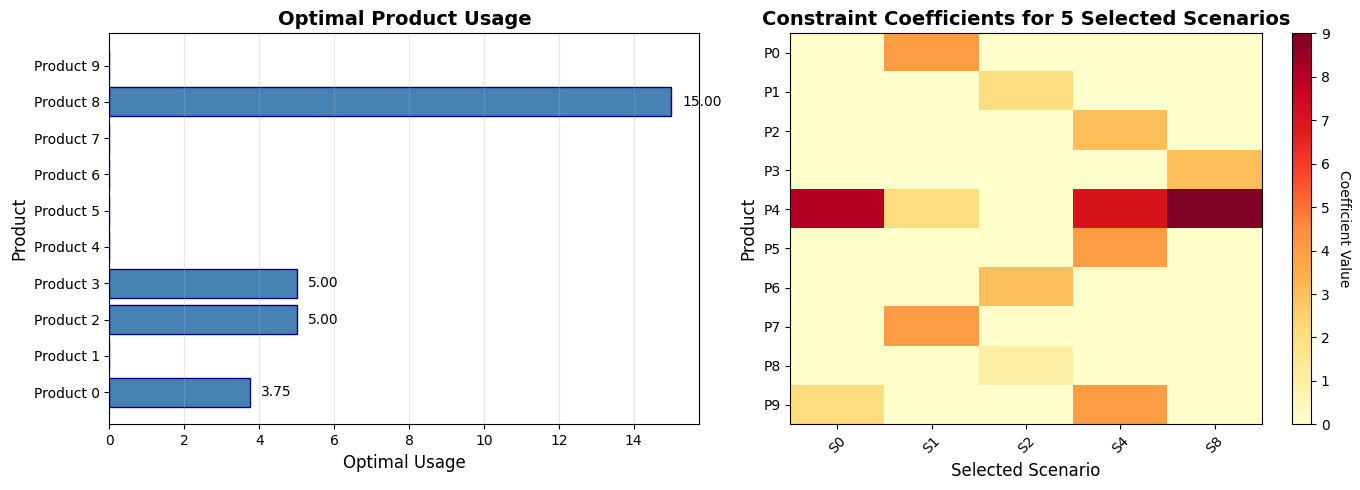

In [12]:
import matplotlib.pyplot as plt

# Plot 1: Optimal Product Usage (Bar Chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart showing optimal usage per product
products = [f"Product {i}" for i in range(N)]
ax1.barh(products, solution, color='steelblue', edgecolor='navy')
ax1.set_xlabel('Optimal Usage', fontsize=12)
ax1.set_ylabel('Product', fontsize=12)
ax1.set_title('Optimal Product Usage', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(solution):
    if v > 1e-6:
        ax1.text(v + 0.3, i, f'{v:.2f}', va='center', fontsize=10)

# Plot 2: Selected Scenarios Heatmap
# Extract coefficients for selected scenarios only from sparse matrix
selected_scenarios_list = sorted(added_scenarios)
# Get columns for selected scenarios and convert to dense array
scenario_data = HIST[:, selected_scenarios_list].toarray()

im = ax2.imshow(scenario_data, cmap='YlOrRd', aspect='auto')
ax2.set_xlabel('Selected Scenario', fontsize=12)
ax2.set_ylabel('Product', fontsize=12)
ax2.set_title(f'Constraint Coefficients for {len(selected_scenarios_list)} Selected Scenarios', 
              fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(selected_scenarios_list)))
ax2.set_xticklabels([f"S{s}" for s in selected_scenarios_list], rotation=45)
ax2.set_yticks(range(N))
ax2.set_yticklabels([f"P{i}" for i in range(N)])

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Coefficient Value', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()